In [1]:
import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
#Define state
class AgentState(MessagesState):
    next_agent: str #which agent should go next

"""All messages exchanged so far  
(inherited from MessagesState)

A custom field added: next_agent  
(used for routing logic)"""

In [3]:
#simple search tool
@tool
def search_web(query: str) -> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

In [4]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

###Define Agents

In [5]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    #system message for context
    system_msg = SystemMessage(content="You are a research assistant, use the search_web tool to find the relevant information about the user request")

    #calling llm with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg]+messages)

    # If tool call exists → route to tools
    if hasattr(response, "tool_calls") and response.tool_calls:
        return {
            "messages": [response],
            "next_agent": "tools"
        }

    # Otherwise → go to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [6]:
def writer_agent(state: AgentState):
    """Writer agent that creates summary"""

    messages = state["messages"]

    #system message
    system_message = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

    response = llm.invoke([system_message]+messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

###Build Graph

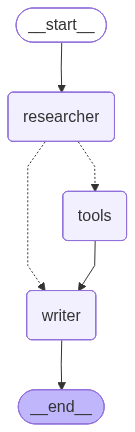

In [7]:
workflow = StateGraph(MessagesState)

#nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("tools", ToolNode([search_web]))

#define flow
workflow.add_edge(START, "researcher")
workflow.add_conditional_edges(
    "researcher",
    lambda state: state["next_agent"],
    {
        "tools": "tools",
        "writer": "writer"
    }
)
workflow.add_edge("tools", "writer")
workflow.add_edge("writer", END)

#compile
final_workflow = workflow.compile()

final_workflow

In [8]:
response = final_workflow.invoke({
    "messages": "Research about the usecases of agentic ai in IT industry"
    })

C:\Users\davis\AppData\Local\Temp\ipykernel_19412\807379345.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


In [9]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Research about the usecases of agentic ai in IT industry
================================== Ai Message ==================================
Tool Calls:
  search_web (call_KDKts8pODWNM0igK1oSfYNBU)
 Call ID: call_KDKts8pODWNM0igK1oSfYNBU
  Args:
    query: use cases of agentic AI in IT industry
================================= Tool Message =================================
Name: search_web

[{'title': 'Agentic AI Use Cases That Prove the Power of Intelligent Automation', 'url': 'https://www.moveworks.com/us/en/resources/blog/agentic-ai-examples-use-cases', 'content': "Table of contents\n\n## Highlights\n\n Agentic AI has rapidly evolved beyond traditional chatbots, enabling autonomous, multi-step workflow execution across enterprise systems.\n The highest-impact use cases share common traits: repetitive processes, clear policies, cross-system dependencies, and measurable business outcomes.\n Early adopters 